# Task Planning

## Planning vs. Learning

In Learning:
- Decisions by induction.
- No prior knowledge required.
- Reactive decisions for the given observation.
- Works well in short-horizon tasks with clear environment guidance.

In Planning:
- Decisions by instruction.
- Requires a model of the world.
- Reason over the model until
  - a solution is found
  - proven no solution exists
  - resource limit reached
- Works well for long-horizon tasks

Often likened to system 1 / system 2 thinking from Daniel Kahneman's [Thinking, Fast and Slow](https://mitpressbookstore.mit.edu/book/9780374533557)

## The Blocksworld Domain

- Manipulate multiple blocks that can be stacked.
- State features: block X on table, block X on block Y, block X is clear on top, holding block X. **Fully observable**
- Actions: pick-up, put-down, stack, unstack. **Deterministic outcomes**
- Start from initial blocks layout, reach goal blocks layout.

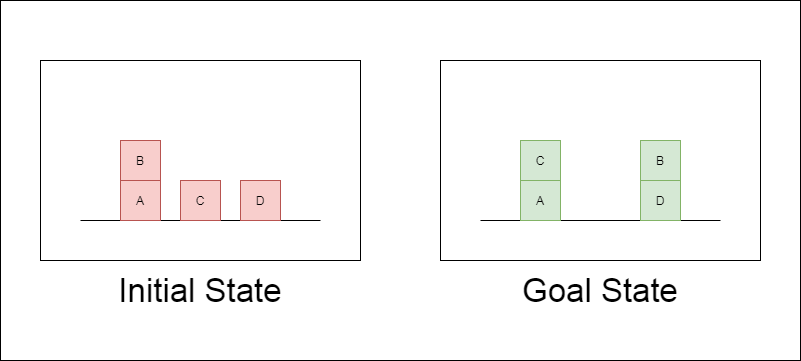


[Image source](https://apoorvdixit619.medium.com/goal-stack-planning-for-blocks-world-problem-41779d090f29)

How do we model this problem?

## STRIPS (recap)

A STRIPS problem is a tuple $\langle F, I, A, G, C \rangle$ where
- $F$ is a set of state features called "fluents".
- $I \subseteq F$ is the initial state.
- $A$ is a set of actions, defined by their preconditions (when they are applicable) and effects (how do they change the state).
- $G \subseteq F$ is the goal condition.
- $C:A \to \mathbb{R}$ is a non-negative cost function.

A Problem modeled in STRIPS is a type of **classical planning** problem.

We can define Blocksworld as a STRIPS problem as follows:
- $F = $ all combinations of the predicates with compatible parameter types e.g., `on(a, b)`, `ontable(c)`, `clear(a)`, `handempty(robot)`, etc.
- $I = $ the set of predicates in the `:init` section of the problem file: `{clear(a), clear(b), clear(c), ontable(a), ontable(b), ontable(c), handempty(robot)}`.
- $A = $ all combinations of the actions with compatible parameter types e.g., `pick-up(a, robot)`, `stack(a, b, robot)`, etc. Preconditions and effects are defined in the `:precondition` and `:effect` sections of each action. "Delete" effects are indicated with `not`, and the rest are "add" effects.
- $G = $ the set of predicates in the `:goal` section of the problem file: `{on(d, c), on(c, b), on(b, a)}`.
- $C = $ we can assume unit cost for each action unless specified otherwise.

How do we represent this problem on the computer?

## PDDL: The Planning Domain Definition Language

- Long-standing standard for describing planning problems, introduced in [this paper](https://www.semanticscholar.org/paper/PDDL-the-planning-domain-definition-language-McDermott-Ghallab/d82c6b8081343b2eae63d45feefe630233ad60e1) in 1998.
- Lisp-like syntax, designed to be both human-readable and machine-readable.
- PDDL files divided into two parts:
  - the domain file - captures the general actions and predicates that define the environment
  - the problem file - specifies the objects in the problem, the initial state, and the goal state.

Why is it useful to divide the domain and problem files?

### Blocksworld in PDDL
#### Domain file

```lisp
; domain.pddl
(define (domain blocks)
    (:requirements :strips :typing)
    (:types block robot)
    (:predicates 
        (on ?x - block ?y - block)
        (ontable ?x - block)
        (clear ?x - block)
        (handempty ?x - robot)
        (holding ?x - block)
    )

    (:action pick-up
        :parameters (?x - block ?robot - robot)
        :precondition (and
            (clear ?x) 
            (ontable ?x) 
            (handempty ?robot)
        )
        :effect (and
            (not (ontable ?x))
            (not (clear ?x))
            (not (handempty ?robot))
            (holding ?x)
        )
    )

    (:action put-down
        :parameters (?x - block ?robot - robot)
        :precondition (and 
            (holding ?x)
        )
        :effect (and 
            (not (holding ?x))
            (clear ?x)
            (handempty ?robot)
            (ontable ?x))
        )

    (:action stack
        :parameters (?x - block ?y - block ?robot - robot)
        :precondition (and
            (holding ?x) 
            (clear ?y)
        )
        :effect (and 
            (not (holding ?x))
            (not (clear ?y))
            (clear ?x)
            (handempty ?robot)
            (on ?x ?y)
        )
    )

    (:action unstack
        :parameters (?x - block ?y - block ?robot - robot)
        :precondition (and
            (on ?x ?y)
            (clear ?x)
            (handempty ?robot)
        )
        :effect (and 
            (holding ?x)
            (clear ?y)
            (not (clear ?x))
            (not (handempty ?robot))
            (not (on ?x ?y))
        )
    )
)
```

### Blocksworld in PDDL
#### Example problem file

```lisp
; problem.pddl
(define (problem blocks)
    (:domain blocks)
    (:objects 
        a - block
        b - block
        c - block
        robot - robot
    )
    (:init 
        (clear a) 
        (clear b) 
        (clear c) 
        (ontable a) 
        (ontable b)
        (ontable c) 
        (handempty robot)
    )
    (:goal (and (on d c) (on c b) (on b a)))
)
``` 

_Question: in natural language, what is the problem described in this PDDL file?_

### PDDL to STRIPS

```lisp
(define (domain blocks)
    (:requirements :strips :typing)
    ...
```

Notice that the domain requires the `:strips` feature. This indicates that the domain uses the STRIPS representation as we saw in the lectures. In fact, it is fairly straightforward to map this problem definition to STRIPS $\langle F, I, A, G, C \rangle$:

- $F = $ all combinations of the predicates with compatible parameter types e.g., `on(a, b)`, `ontable(c)`, `clear(a)`, `handempty(robot)`, etc.
- $I = $ the set of predicates in the `:init` section of the problem file: `{clear(a), clear(b), clear(c), ontable(a), ontable(b), ontable(c), handempty(robot)}`.
- $A = $ all combinations of the actions with compatible parameter types e.g., `pick-up(a, robot)`, `stack(a, b, robot)`, etc. Preconditions and effects are defined in the `:precondition` and `:effect` sections of each action. "Delete" effects are indicated with `not`, and the rest are "add" effects.
- $G = $ the set of predicates in the `:goal` section of the problem file: `{on(d, c), on(c, b), on(b, a)}`.
- $C = $ we can assume unit cost for each action unless specified otherwise.

By using PDDL, we were able to define the blocksworld problem in a structured and formal way that is far more compact than its STRIPS counterpart, making it readable for both humans and machines.

Not all PDDL problems can be mapped to standard STIPS representations. PDDL is a powerful language for defining planning problems that supports a variety of features beyond the basic STRIPS representation, such as quantifiers, conditional effects, and non-deterministic actions. The purpose of the `:requirements` section is to specify which features of PDDL are used in the domain. Planners support a specific subset of PDDL features by design, whether it be just STRIPS or more advanced features, so the `:requirements` section helps ensure compatibility between the problem definition and the planner being used.

## Simulating Blocksworld with PDDLGym

[PDDLGym](https://github.com/tomsilver/pddlgym) is a python library that integrates PDDL-defined planning problems with [OpenAI Gym](https://github.com/openai/gym) environments. OpenAI Gym is a, now outdated (see [gymnasium](https://gymnasium.farama.org/index.html)), toolkit for developing decision-making environments, most notably used for reinforcement learning research. It defines a standard interface for environments, allowing researchers to easily compare different algorithms. PDDLGym allows users to create environments based on PDDL definitions, enabling the use of planning algorithms within the Gym framework.

PDDLGym already implements some common planning domains, including blocksworld. Let's create a PDDLGym environment for the blocksworld problem we defined earlier.

In [ ]:
import pddlgym

env = pddlgym.make("PDDLEnvBlocks-v0")
env.fix_problem_index(0)  # select a specific problem for now
env

### Gym API

The basic Gym interface consists of two methods:
- `reset()`: Resets the environment to an initial state and returns the initial observation and debug information.
- `step(action)`: Takes an action in the environment and returns a tuple containing the next observation and additional info.

Upon reset, PDDLGym chooses a random problem file from a preset directory and initializes the environment accordingly. Moreover, some domains, including blocksworld, have a built-in visualizer, callable using the `.render()` method. Let's see how we can use PDDLGym to simulate the blocksworld problem we defined earlier.

In [ ]:
# blocksworld visualizer is based on matplotlib
%matplotlib inline

obs, debug_info = env.reset()
env.render();
debug_info

### Internal PDDL

In [ ]:
debug_info 

As we can see, the environment is initialized with files ending with `.pddl` extensions, indicating that they are PDDL files, similar to the ones we defined earlier.

In [ ]:
with open(debug_info['problem_file'], 'r') as f:
    print(f.read())

### Performing Actions

The Gym interface also includes an action space, which defines which actions are supported by the environment. Let's take a random action in the environment and see how the state changes.

**NOTE**: The chosen action may be inapplicable in the current state, in which case the state remains unchanged. rerun multiple times to see different actions.

In [ ]:
action = env.action_space.sample(obs)
print('applying action:', action)

obs, reward, done, trun, info = env.step(action)
env.render();

We now need to find a sequence of actions that will bring us to the goal.

## The Unified Planning Framework

- Planning problems come in different shapes and sizes, and different planners support different types of problems.
- Even within PDDL, there are a multitude of features making it difficult for one planner to support them all.

![image.png](images/AIPlan4EU.png)

- The [Unified Planning Framework (UPF)](https://github.com/aiplan4eu/unified-planning) is the gold standard for defining and solving planning problems in Python.
  - Provides a common interface for defining planning problems, regardless of the underlying representation or planner being used.
  - Supports a wide range of planning domains and problem types, making it a versatile tool for researchers and practitioners in the field of automated planning.

### Defining Blocksworld in UPF

UPF enables users to define planning problems in a high-level, abstract manner, directly in python using its API. This is covered extensively in the [documentation](https://unified-planning.readthedocs.io/en/latest/notebooks/tutorial/modeling.html). However, **UPF also supports loading PDDL files directly**, either from a file or from a string, making it easy to use existing PDDL definitions. Let's load our let's load the blocksworld PDDL files from PDDLGym.

### Defining Blocksworld in UPF
#### PDDLGym compatibility

PDDLGym does not use standard PDDL syntax. It defines action predicates within the PDDL files. We will need to filter these out when loading the PDDL files into UPF.

In [ ]:
from unified_planning.environment import get_environment

# PDDLGym sometimes names objects the same as their types. UPF by default raises an error in such cases.
# We disable this error for compatibility.
upf_env = get_environment()
upf_env.error_used_name = False


def _update_pddlgym_pddl_for_upf_compatibility(
    domain_file: str, problem_file: str
) -> str:
    """
    In PDDLGym, actions are sometimes also included as predicates in the domain and problem files.
    This causes issues when parsing the PDDL files with UPF, as UPF does not support this syntax.
    This function removes action predicates from the domain and problem PDDL strings.
    
    NOTE: This is not necessary, and it is enough to disable name reuse with `upf_env.error_used_name = False`
          as above. We do this here to demonstrate a minimal PDDL representation.
    """

    with open(domain_file, "r") as f:
        domain_lines = f.readlines()

    # remove duplicate action predicates.
    # first, find the line that lists actions in comment, e.g., "; (:actions pickup putdown stack unstack)"
    action_line_index = None
    for i, line in enumerate(domain_lines):
        if line.strip().startswith(";") and "(:actions" in line:
            action_line_index = i
            break

    # if no action line found, return as is
    if action_line_index is None:
        return "".join(domain_lines), "".join(problem_lines)

    # list all actions
    actions = (
        domain_lines[action_line_index]
        .strip()
        .replace(";", "")
        .replace("(:actions", "")
        .replace(")", "")
        .split()
    )
    unique_actions = set()
    for action in actions:
        if action not in unique_actions:
            unique_actions.add(action)

    # drop all lines where the action appears as a predicate.
    # this is defined as a line that starts with "(<action_name> "
    domain_lines = [
        line
        for line in domain_lines
        if not any(line.strip().startswith(f"({action} ") for action in unique_actions)
    ]

    # remove action literals in initial state
    with open(problem_file, "r") as f:
        problem_lines = f.readlines()
    problem_lines = [
        line
        for line in problem_lines
        if not any(line.strip().startswith(f"({action} ") for action in unique_actions)
    ]

    return "".join(domain_lines), "".join(problem_lines)


### Defining Blocksworld in UPF
#### Loading Blocksworld PDDL

We can now load the problem into UPF:

In [ ]:
from unified_planning.io import PDDLReader
from unified_planning.model import Problem


def get_upf_pddl_problem_from_pddlgym_info(info: dict) -> Problem:
    domain_file = info["domain_file"]
    problem_file = info["problem_file"]

    # UPF can read the PDDL files directly. However, PDDLGym uses special action predicates that are
    # not necessary in the general case. We preprocess the PDDL strings to remove these action predicates.
    # This is not necessary, and it is enough to disable name reuse with `upf_env.error_used_name = False`
    # as above. We do this here to demonstrate a minimal PDDL representation.
    domain_pddl_str, problem_pddl_str = _update_pddlgym_pddl_for_upf_compatibility(
        domain_file, problem_file
    )

    reader = PDDLReader()
    problem = reader.parse_problem_string(domain_pddl_str, problem_pddl_str)
    return problem


blocks_problem = get_upf_pddl_problem_from_pddlgym_info(debug_info)
blocks_problem

Looking at the problem object representation above, we can see that it captures everything defined in the PDDL:
- `fluents`: The predicates defined in the domain file, e.g., `on`, `ontable`, `clear`, etc.
- `actions`: The actions defined in the domain file, e.g., `pick-up`, `put-down`, `stack`, `unstack`.
- `initial values`: The initial state defined
- `objects`: The objects defined in the problem file, e.g., blocks `a`, `b`, `c`, etc., and the `robot`.

## Solving Blocksworld

_Question: What algorithms do we know that can solve blocksworld?_

Let's try breadth-first search (BFS)

In [ ]:
from unified_planning.engines.sequential_simulator import UPSequentialSimulator


def bfs(problem: Problem):
    sim = UPSequentialSimulator(problem)
    cur_state = sim.get_initial_state()
    visited = set()
    queue = [(cur_state, [])]  # (state, path)
    while queue:
        state, path = queue.pop(0)
        if sim.is_goal(state):
            return path
        visited.add(state)
        for action, params in sim.get_applicable_actions(state):
            next_state = sim.apply(state, action, params)
            if next_state not in visited:
                queue.append((next_state, path + [action(*params)]))
    
    raise Exception("No solution found")

bfs_solution = bfs(blocks_problem)
bfs_solution

### Convert to PDDLGym format

- PDDLGym does not accept UPF-style actions.
- Such incompatibilities are common in practice.

In [ ]:
from pddlgym.core import PDDLEnv
from pddlgym.structs import Literal, Type
from unified_planning.plans.plan import ActionInstance
from difflib import get_close_matches

def convert_upf_action_to_pddlgym_action(action: ActionInstance, env: PDDLEnv) -> Literal:
    action_predicates = env.action_space.predicates

    # find the predicate whose name is the closest to the action name. does not have to be indentical
    # Find the predicate that matches the action name
    matching_pred_name = get_close_matches(
        action.action.name,
        [pred.name for pred in action_predicates],
        n=len(action_predicates)
    )[0]
    action_predicate = next(
        pred for pred in action_predicates if pred.name == matching_pred_name
    )

    # find the matching variables types of the action
    action_variables = []
    action_params_gen = iter(action.actual_parameters)
    for var_type_str in action_predicate.var_types:
        param = next(action_params_gen)
        if var_type_str != param.type.name:
            # check if the type is "default" and the param type is "object"
            if var_type_str != "default" or param.type.name != "object":
                continue
        var_name = param.object().name
        var_type = Type(param.type.name)
        action_variables.append(var_type(var_name))


    return Literal(predicate=action_predicate, variables=action_variables)

pddl_gym_plan = [convert_upf_action_to_pddlgym_action(act, env) for act in bfs_solution]
pddl_gym_plan

### Simulating the Path

In [ ]:
# stop inline rendering of blocksworld frames.
# we will render the video frames at the end
%matplotlib agg

import matplotlib.pyplot as plt
import mediapy as media

def simulate_plan(env: PDDLEnv, pddl_gym_plan: list[Literal]):
    frames = [env.render()[:, :, :3]]  # initial frame
    for action in pddl_gym_plan:
        obs, reward, done, truncated, debug_info = env.step(action)
        frames.append(env.render()[:, :, :3])  # drop alpha channel
    
    # pddlgym renders blocksworld using matplotlib.
    # in notebooks use the "agg" backend, figures are aggregated in memory.
    # We close all figures here to avoid memory leaks.
    plt.close('all')

    return frames, done

env.reset()  # fixed env to the same problem index. no problem shuffle here
frames, done = simulate_plan(env, pddl_gym_plan)

print(f'goal reached: {done}')
media.show_video(frames, fps=2)

## That's it! We've solved blocksworld! Or have we...

BFS seems like a viable solution for solving blocksworld optimally. Let's capture the general formula.

In [ ]:
%load_ext jupyter_timeout

from IPython.display import clear_output


def solve_pddl_env_bfs(env: PDDLEnv):
    obs, debug_info = env.reset()
    problem = get_upf_pddl_problem_from_pddlgym_info(debug_info)

    init_frame = env.render()[:, :, :3]  # initial frame
    print('solving problem with BFS...')
    media.show_image(init_frame)

    plan = bfs(problem)

    clear_output(wait=True)

    pddlgym_actions = [convert_upf_action_to_pddlgym_action(act, env) for act in plan]
    frames, done = simulate_plan(env, pddlgym_actions)

    print(f'goal reached: {done}')
    media.show_video(frames, fps=2)

There are 5 variants of the problem. Let's try to solve all of them.

In [ ]:
%%timeout 30

env.fix_problem_index(1)
solve_pddl_env_bfs(env)

In [ ]:
%%timeout 30

env.fix_problem_index(2)
solve_pddl_env_bfs(env)

In [ ]:
%%timeout 30

env.fix_problem_index(3)
solve_pddl_env_bfs(env)

This is taking too long! Maybe BFS is not as good as we thought.

_Question: Can we do better?_

## Heuristics

- In IAI we learned about informed search via the A* algorithm using heuristics.
- A heuristic is a function that quantifies how close the agent is to a goal state.

![heuristic](images/heuristic-search.png)

_Question: What heuristics can we use in blocksworld?_

Luckily, we don't have to come up with new heuristics for every domain.

## Domain-independent Heuristics

- We want a general formula for heuristics that work for any domain.

- We can take advantage of the STRIPS formulation structure to do so.
  - Recall that an action $a\in A$ is comprised of the precondition, add effect, and delete effect, denoted $pre(a),add(a),del(a)\subseteq F$.
  - At state $s\subseteq F$, action $a$ is applicable if $pre(a) \subseteq s$.
  - Applying $a$ at state $s$ yields a new state $s' = (s \setminus del(a))\cup add(a)$

- Example: delete relaxation
  - Create relaxed planning problem $\langle F, A'=\{a' | a\in A\}, I, G, C \rangle$ where $pre(a')=pre(a), add(a')=add(a)$, but $del(a')=\emptyset$
  - Solve the relaxed problem, and use the plan cost as the heuristic.
  - Solutions will always be shorter in the relaxed problem $\Longrightarrow$ admissible heuristic

## The Fast Downward Planning System

![fd](images/fast-downward-logo.png)

[Fast Downward](https://www.fast-downward.org/) (FD) has been the go-to planning system in the planning community since 2006.
- Note: This is not a planner, it is a planning system
- FD performs many optimizations under the hood, e.g., reducing the problem to only the most relevant fluents.
- Ultimately, FD runs A* with a given heuristic.
- In UFP, by default, FD runs the fast-forward heuristic, known for finding plans incredibly fast.

## Solving Blocksworld with Fast Downward

- Let's use the Fast Downward planner that we installed earlier to solve this problem.
- Unlike BFS, FD runs natively within UFP. We can use the `OneshotPlanner` interface.

In [ ]:
from unified_planning.shortcuts import OneshotPlanner

# obs, debug_info = env.reset()
# blocks_problem = get_upf_pddl_problem_from_pddlgym_info(debug_info)
# blocks_problem

with OneshotPlanner(name='fast-downward') as planner:
    plan_res = planner.solve(blocks_problem)

print(plan_res)

### Executing the plan

In [ ]:
# convert actions to PDDLGym compatible
pddlgym_actions = [convert_upf_action_to_pddlgym_action(act, env) for act in plan_res.plan.actions]

# execute the plan in PDDLGym
# remember that the `blocks_problem` we solved was for fixed index 0
env.fix_problem_index(0)
env.reset()
frames, done = simulate_plan(env, pddlgym_actions)

# check goal reached
print(f'goal reached: {done}')

# show execution
media.show_video(frames, fps=2)

It works! But is it optimal?

## Optimal FD

In [ ]:
media.show_video(frames, fps=2)

- Notice how the planner makes an extra move by redundantly putting the green block on top of the blue block and later unstacking it again.
- Fast Downward's default options in UFP are meant for finding a valid plan quickly, rather than the optimal plan.
- The fast-forward heuristic is not admissible, so the default Fast Downward configuration does not guarantee an optimal solution.

To guarantee optimality, we can configure Fast Downward to use A* search with the admissible LM-Cut heuristic. This is equivalent to calling the `fast-downward-opt` planner which comes bundled in the `up-fast-downward` package. We can do this by specifying the planner name when creating the `OneshotPlanner` object to be `fast-downward-opt`. However, we can do this in a more general way.

### Optimal Planners in UFP

Recall that different problems require different features and different planners support different features. UPF provides an automatic way to select the best planner for a given problem based on the problem's features. Each problem has a `kind` property that captures the features used in the problem, e.g., whether it is a classical planning problem, whether it uses typing, whether it has negative preconditions, etc. Let's check the kind of our blocksworld problem:

In [ ]:
print(blocks_problem.kind)

As we can see, our blocksworld problem requires few features. These happen to be supported by the Fast-downward planner. To force UPF to select the optimal version of Fast Downward, we can specify that we want an optimality guarantee when creating the planner:

In [ ]:
from unified_planning.engines import PlanGenerationResultStatus

with OneshotPlanner(problem_kind=blocks_problem.kind,
                    optimality_guarantee=PlanGenerationResultStatus.SOLVED_OPTIMALLY) as planner:
    plan_res = planner.solve(blocks_problem)
print(plan_res)

The above will choose any available planner that supports this problem and guarantees an optimal plan. Notice how the redundant stacking and unstacking are now gone.

### Optimality Check

Let's check that our new plan is indeed optimal:

In [ ]:
env.reset()  # fixed env to the same problem index. no problem shuffle here

pddl_gym_plan = [convert_upf_action_to_pddlgym_action(act, env) for act in plan_res.plan.actions]
frames, done = simulate_plan(env, pddl_gym_plan)

print(f'goal reached: {done}')
media.show_video(frames, fps=2)

## Scaling with FD

This is the same general pipeline we used with BFS.

In [ ]:
def solve_pddl_env_fd_optimal(env: PDDLEnv):
    obs, debug_info = env.reset()
    problem = get_upf_pddl_problem_from_pddlgym_info(debug_info)

    init_frame = env.render()[:, :, :3]  # initial frame
    print('solving problem with BFS...')
    media.show_image(init_frame)

    with OneshotPlanner(problem_kind=problem.kind,
                        optimality_guarantee=PlanGenerationResultStatus.SOLVED_OPTIMALLY,) as planner:
        plan = planner.solve(problem)

    clear_output(wait=True)

    pddlgym_actions = [convert_upf_action_to_pddlgym_action(act, env) for act in plan.plan.actions]
    frames, done = simulate_plan(env, pddlgym_actions)

    print(f'goal reached: {done}')
    media.show_video(frames, fps=2)

Let's see if it scales up to the harder instances of blocksworld.

In [ ]:
%%timeout 30

env.fix_problem_index(1)
solve_pddl_env_fd_optimal(env)

In [ ]:
%%timeout 30

env.fix_problem_index(2)
solve_pddl_env_fd_optimal(env)

In [ ]:
%%timeout 30

env.fix_problem_index(3)
solve_pddl_env_fd_optimal(env)

In [ ]:
%%timeout 30

env.fix_problem_index(4)
solve_pddl_env_fd_optimal(env)

_Question: Can we use this pipeline to solve different domains?_

In theory, yes. Fast Downward can solve all PDDL problems defined in PDDLGym. However, The different problems have specific requirements in how they handle actions, meaning we must adapt our PDDL cleaning and action mapping function to each domain. In robotics, this kind of adaptation is common when switching between different robot platforms and environments. Even though we have abstracted away the difficulties revolving around the physical robot, we are still reminded of this difficulty due to the incompatibility between PDDLGym and UPF action representations.

## Conclusion

In this tutorial, we solved the blocksworld domain.
- We modeled the problem using the STRIPS formulation.
- We represented the problem with PDDL.
- We solved it using blind search and saw that it was not scalable.
- We solved it using informed search, optimally and suboptimally.

Task planning is an incredibly powerful and versatile tool.
- It can solve a wide array of problems.
- It Typically provides guarantees on the solution quality.
- It can reason over a long horizon.
- It uses all the resources it is given.
- In many cases, custom heuristics are unnecessary.

But task planning also has many limitations.
- It is not scalable to very large problems.
  - Many problems still require custom heuristics to solve.
- It requires an accurate model of the world.
- It cannot adapt to unexpected events or changes in the environment.
- It is discrete by design, and cannot consider continuous variables, uncertainty, or real-time dynamics.
  - There are extensions to PDDL that handle these, but typically, only small problems can be solved.
- It relies on pre-implemented high-level actions.

In the coming lectures and tutorials, we will see how learning approaches can help mitigate some of these limitations